Data Loading and Preparation

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download the Churn Modelling Dataset [cite: 44]
path = kagglehub.dataset_download("ahmedgaitani/customer-churn-prediction-dataset")

# List the contents of the downloaded directory to find the correct file name
print("Contents of downloaded directory:", os.listdir(path))

file_name = "customer_churn_prediction_dataset.csv"
file_path = os.path.join(path, file_name)

df = pd.read_csv(file_path)

# Drop unnecessary columns that don't affect churn. Based on inspection, 'customerID' is present,
# but 'RowNumber' and 'Surname' are not in this dataset.
df = df.drop(['customerID'], axis=1)

print("Dataset Shape:", df.shape)
display(df.head())

Using Colab cache for faster access to the 'customer-churn-prediction-dataset' dataset.
Contents of downloaded directory: ['customer_churn_prediction_dataset.csv']
Dataset Shape: (300, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,5,No,Yes,No,No,Yes,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes
1,Female,0,No,No,42,Yes,No phone service,DSL,Yes,Yes,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes
2,Male,0,No,No,61,Yes,No phone service,No,No,Yes,No,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes
3,Male,1,No,Yes,22,Yes,No,No,No internet service,No internet service,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No
4,Male,1,Yes,Yes,21,No,No,DSL,No,No,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes


Encoding Categorical Features

In [9]:
# One-Hot Encoding for Gender
df = pd.get_dummies(df, columns=['gender'], drop_first=True)

print("Columns after encoding:", df.columns.tolist())

Columns after encoding: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male']


Exploratory Data Analysis (EDA)

/tmp/ipykernel_7433/650768495.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='pastel')


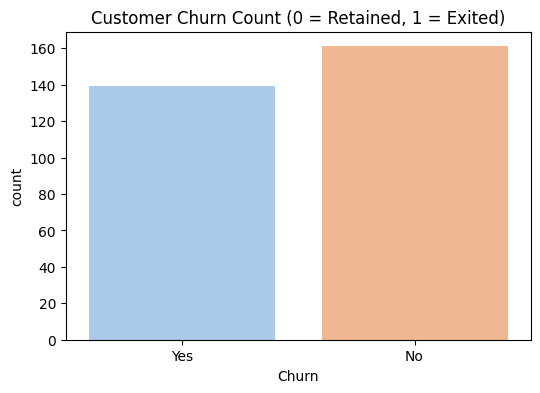

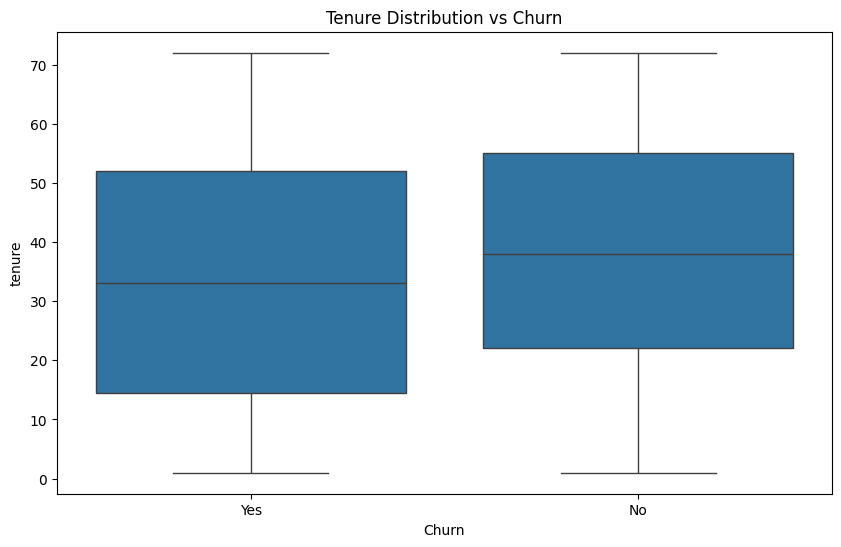

In [10]:
# Visualize Churn Rate [cite: 86]
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='pastel')
plt.title('Customer Churn Count (0 = Retained, 1 = Exited)')
plt.show()

# Relationship between Tenure and Churn (as Age is not available)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure Distribution vs Churn')
plt.show()

Model Training and Feature Importance

Accuracy: 0.47

Confusion Matrix:
 [[21 13]
 [19  7]]


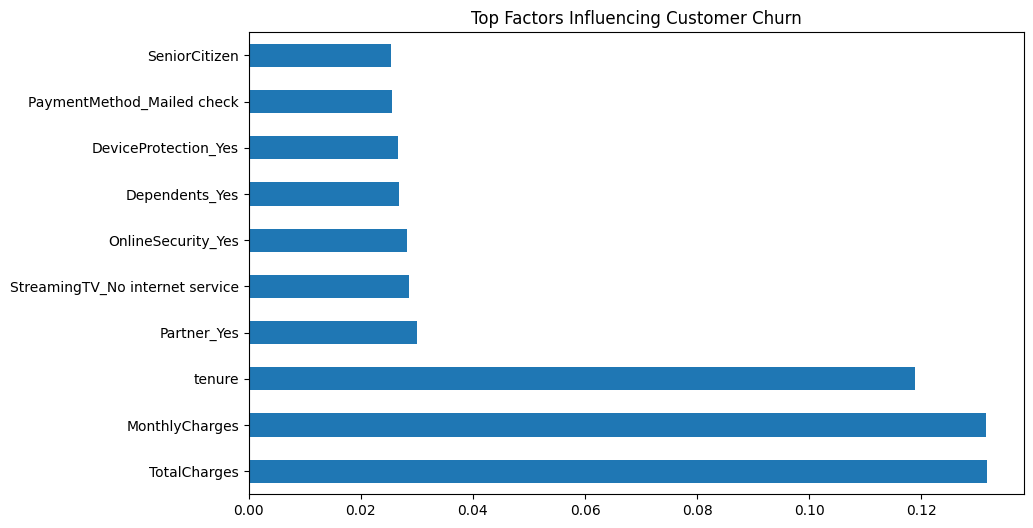

In [12]:
# Define Features and Target
# First, convert 'Yes'/'No' in Churn to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Identify categorical columns for one-hot encoding (excluding 'Churn' as it's already handled and the target)
categorical_cols = df.select_dtypes(include='object').columns

# Apply one-hot encoding to remaining categorical columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df.drop('Churn', axis=1)
y = df['Churn']

# Split data [cite: 87]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model [cite: 48]
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions & Evaluation [cite: 88]
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Analyze Feature Importance [cite: 49, 53]
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', figsize=(10, 6))
plt.title('Top Factors Influencing Customer Churn')
plt.show()